<a href="https://colab.research.google.com/github/laurammonteiro/paris-urban-heat-green-inequality/blob/main/01_data_loading_and_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Average median income and poverty rate per arrondissement:


,arrondissement,median_income,poverty_rate
0,1.0,35516.428571,12.571429
1,2.0,31832.777778,15.650000
2,3.0,32575.454545,13.307692
3,4.0,32806.111111,13.140000
4,5.0,35012.812500,11.443750
5,6.0,41280.967742,11.714286
6,7.0,44408.648649,9.887500
7,8.0,43289.259259,10.400000
8,9.0,34606.585366,13.062963
9,10.0,26452.950820,19.566667


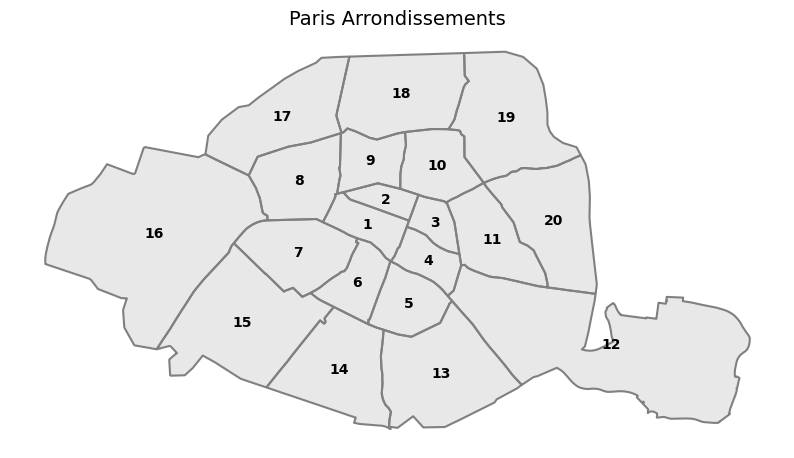

In [1]:
# Clone GitHub repository
import contextlib
!rm -rf paris-urban-heat-green-inequality
!git clone https://github.com/laurammonteiro/paris-urban-heat-green-inequality.git --quiet

with contextlib.redirect_stdout(None):
    %cd paris-urban-heat-green-inequality

# Import libraries
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import matplotlib.patches as mpatches

# Load income CSV
income = pd.read_csv('./data/income_paris_2018.csv', sep=';')

# Load GeoJSON files
iris_geo = gpd.read_file('./data/iris.geojson')
arr = gpd.read_file('./data/arrondissements.geojson')

# Merge IRIS geometries with income data using common ID
income_renamed = income.rename(columns={'IRIS': 'code_insee'})
iris_geo_renamed = iris_geo.rename(columns={'code_iris': 'code_insee'})
income_iris = iris_geo_renamed.merge(income_renamed, on='code_insee')

# Assign arrondissement numbers to IRIS polygons
income_with_arr = gpd.sjoin(income_iris, arr[['geometry', 'c_ar']], how='left', predicate='intersects')

# Extract selected indicators: median income and poverty rate
income_with_arr.rename(columns={
    'DISP_MED18': 'median_income',
    'DISP_TP6018': 'poverty_rate'
}, inplace=True)

# Group by arrondissement and calculate mean
arr_stats = income_with_arr.groupby('c_ar')[['median_income', 'poverty_rate']].mean().reset_index()
arr_stats.rename(columns={'c_ar': 'arrondissement'}, inplace=True)

# Display the result table
print("Average median income and poverty rate per arrondissement:")
display(arr_stats)

# Merge aggregated stats with arrondissement shapes
arr = arr.merge(arr_stats, left_on='c_ar', right_on='arrondissement', how='left')

# Plot base map with arrondissement numbers
fig, ax = plt.subplots(figsize=(10, 10))
arr.boundary.plot(ax=ax, edgecolor='gray')
arr.plot(ax=ax, color='lightgray', alpha=0.5)

# Label each arrondissement
for idx, row in arr.iterrows():
    plt.text(row.geometry.centroid.x, row.geometry.centroid.y, str(row['c_ar']),
             ha='center', va='center', fontsize=10, fontweight='bold')

ax.set_title("Paris Arrondissements", fontsize=14)
ax.axis('off')
plt.show()


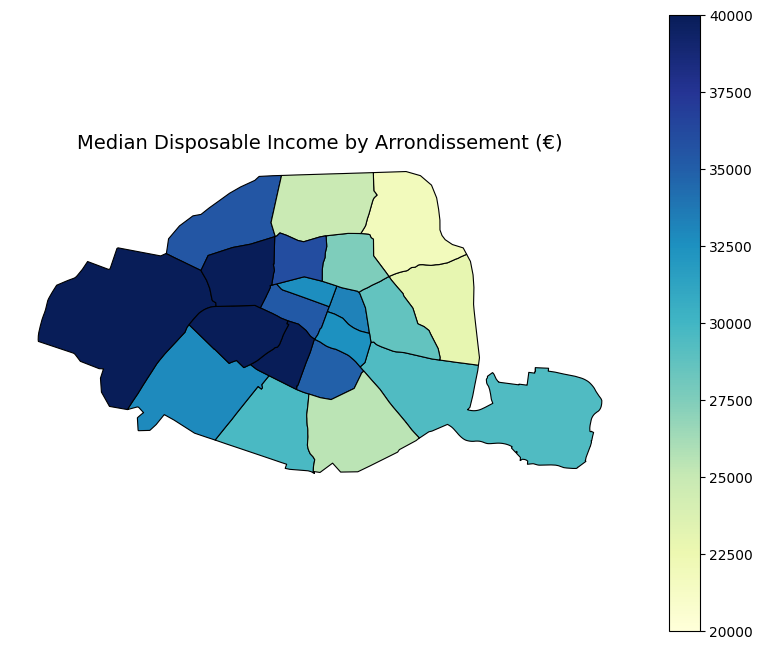

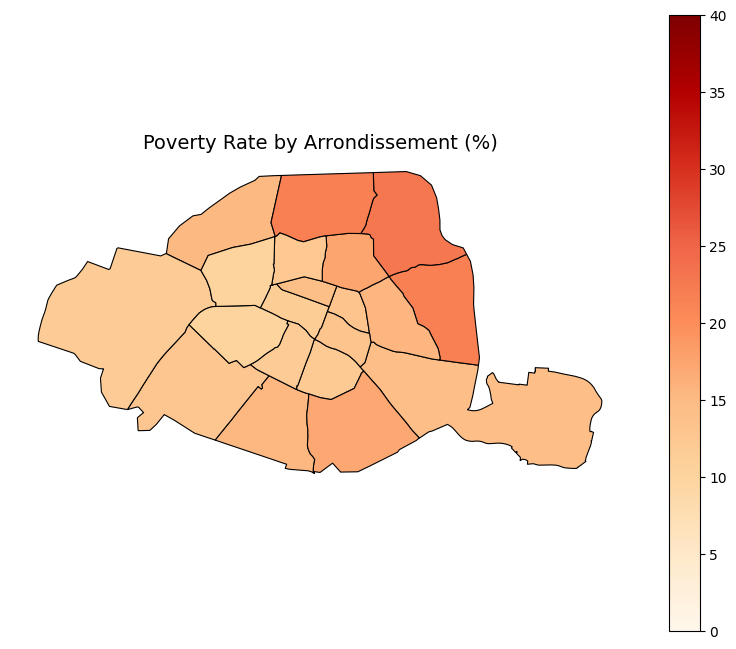

In [ ]:
# Step 2 – Clean & Merge Socioeconomic Data for Visualization

# Filter rows where the INSEE code starts with '751' (Paris arrondissements)
paris_income = income.rename(columns={'IRIS': 'code_insee'}).copy()
paris_income = paris_income[paris_income['code_insee'].astype(str).str.startswith('751')]

# Rename key columns
paris_income.rename(columns={
    'DISP_MED18': 'median_income',
    'DISP_TP6018': 'poverty_rate',
}, inplace=True)

# Extract arrondissement number from the INSEE code
paris_income['arrondissement'] = paris_income['code_insee'].str[3:5].astype(int)

# Aggregate income data by arrondissement (calculate mean)
arrondissement_income = paris_income.groupby('arrondissement')[['median_income', 'poverty_rate']].mean().reset_index()

# Clean previous merge if re-running
cols_to_drop = [col for col in arr.columns if 'income' in col or 'poverty' in col or '_x' in col or '_y' in col]
arr = arr.drop(columns=cols_to_drop, errors='ignore')

# Ensure merge keys match types
arr['c_ar'] = arr['c_ar'].astype(int)
arrondissement_income['arrondissement'] = arrondissement_income['arrondissement'].astype(int)

# Merge the data
arr = arr.merge(arrondissement_income, left_on='c_ar', right_on='arrondissement', how='left')

# Rename c_ar to Arrondissement (for future clarity in plots/tables if needed)
arr = arr.rename(columns={'c_ar': 'Arrondissement'})

# Median income map
arr.plot(column='median_income', cmap='YlGnBu', legend=True,
         figsize=(10, 8), edgecolor='black', linewidth=0.8,
         vmin=20000, vmax=40000)
plt.title("Median Disposable Income by Arrondissement (€)", fontsize=14)
plt.axis("off")
plt.show()

# Poverty rate map
arr.plot(column='poverty_rate', cmap='OrRd', legend=True,
         figsize=(10, 8), edgecolor='black', linewidth=0.8,
         vmin=0, vmax=40)
plt.title("Poverty Rate by Arrondissement (%)", fontsize=14)
plt.axis("off")
plt.show()


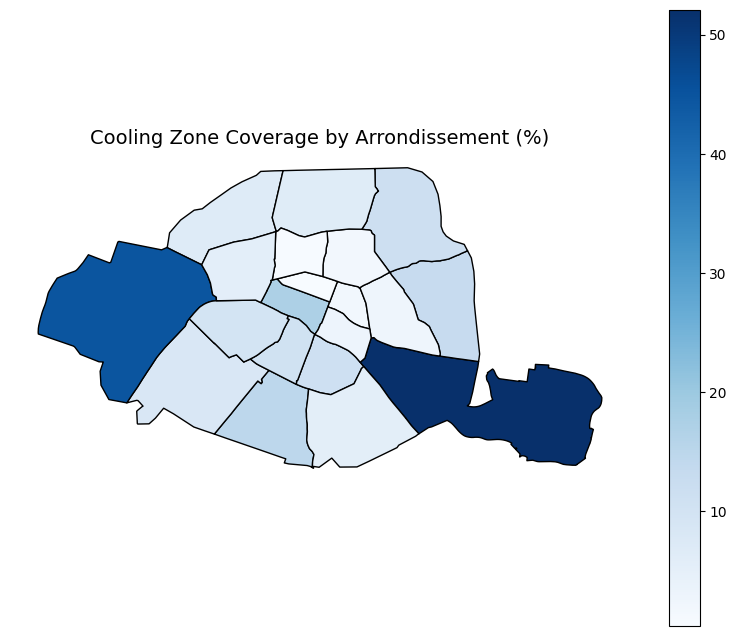

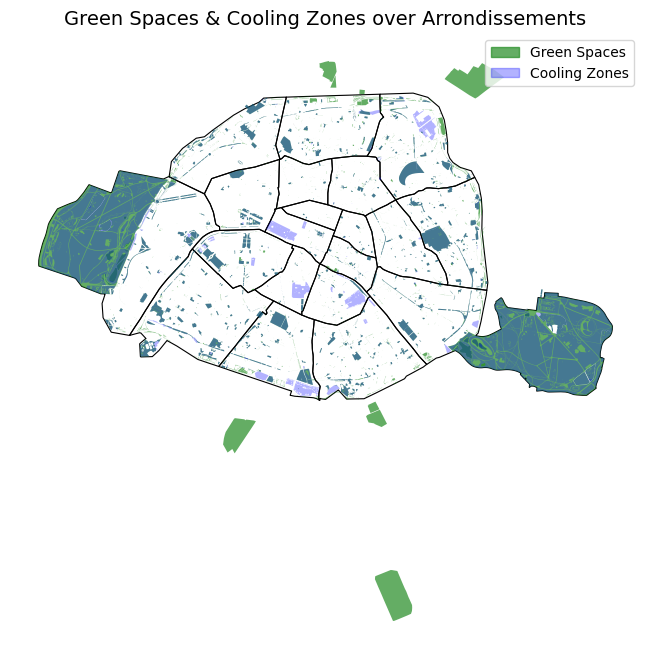

In [ ]:
# Step 3 – Analyze Urban Heat Exposure (Cool Zones + Green Spaces)

# 1. Load the green spaces GeoJSON
green = gpd.read_file('./data/espaces_verts.geojson')

# 2. Reproject geometries for accurate area calculations (France: EPSG 2154)
arr_proj = arr.to_crs(epsg=2154)
cool_proj = cool.to_crs(epsg=2154)

# 3. Calculate % of each arrondissement covered by cooling zones
cool_union = gpd.GeoSeries(cool_proj.geometry).union_all()
arr_proj['cool_area'] = arr_proj.geometry.intersection(cool_union).area
arr_proj['arr_area'] = arr_proj.geometry.area
arr_proj['cool_ratio'] = arr_proj['cool_area'] / arr_proj['arr_area'] * 100

# 4. Visualize coverage by arrondissement
arr_proj.plot(
    column='cool_ratio',
    cmap='Blues',
    legend=True,
    edgecolor='black',
    figsize=(10, 8)
)
plt.title("Cooling Zone Coverage by Arrondissement (%)", fontsize=14)
plt.axis("off")
plt.show()

# 5. Overlay map of green spaces + cooling zones
fig, ax = plt.subplots(figsize=(10, 8))
arr.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.8)
green.plot(ax=ax, facecolor='forestgreen', edgecolor='none', alpha=0.7)
cool.plot(ax=ax, facecolor='blue', edgecolor='none', alpha=0.3)

# Create custom legend handles
green_patch = mpatches.Patch(color='forestgreen', label='Green Spaces', alpha=0.7)
cool_patch = mpatches.Patch(color='blue', label='Cooling Zones', alpha=0.3)

plt.legend(handles=[green_patch, cool_patch])
plt.title("Green Spaces & Cooling Zones over Arrondissements", fontsize=14)
plt.axis("off")
plt.show()



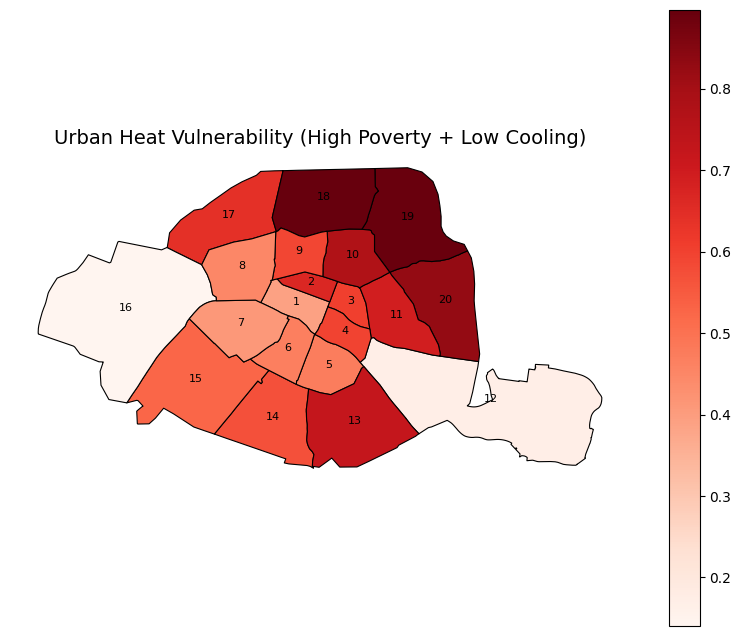

In [ ]:
import re
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Normalize variables
scaler = MinMaxScaler()
arr_proj['poverty_norm'] = scaler.fit_transform(arr_proj[['poverty_rate']])
arr_proj['cool_inv'] = 100 - arr_proj['cool_ratio']
arr_proj['cool_norm'] = scaler.fit_transform(arr_proj[['cool_inv']])
arr_proj['vulnerability'] = (arr_proj['poverty_norm'] + arr_proj['cool_norm']) / 2

# Extract number from 'l_ar' (e.g., '1er Ardt' → '1')
arr_proj['arr_number'] = arr_proj['l_ar'].str.extract(r'(\d+)')

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
arr_proj.plot(
    column='vulnerability',
    cmap='Reds',
    linewidth=0.8,
    ax=ax,
    edgecolor='black',
    legend=True
)

# Label only the number
arr_proj.apply(lambda x: ax.annotate(text=str(x['arr_number']),
                                     xy=x.geometry.centroid.coords[0],
                                     ha='center', fontsize=8), axis=1)

plt.title("Urban Heat Vulnerability (High Poverty + Low Cooling)", fontsize=14)
plt.axis('off')
plt.show()
